In [1]:
!pip install yfinance

# LSTM Stock Prediction Pipeline


In [2]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reproducibility


In [3]:
torch.manual_seed(42)
np.random.seed(42)

# Device


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset Class


In [5]:
class StockDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+self.seq_length, 3]
        return x, y

# Fetch & Preprocess


In [6]:
def fetch_data(symbol, start, end):
    df = yf.download(symbol, start=start, end=end)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df['Average'] = (df['High'] + df['Low']) / 2
    return df

In [7]:
def split_scale(df):
    train_size = int(len(df) * 0.7)
    val_size = int(len(df) * 0.15)
    train = df[:train_size]
    val = df[train_size:train_size+val_size]
    test = df[train_size+val_size:]
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train)
    val_scaled = scaler.transform(val)
    test_scaled = scaler.transform(test)
    return train_scaled, val_scaled, test_scaled, scaler

# LSTM Model


In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

# Training Function


In [9]:
def train_model(model, train_loader, val_loader, epochs=20, save_path="best_model.pth"):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            preds = model(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                preds = model(x)
                loss = criterion(preds, y)
                val_loss += loss.item()
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss
            }, save_path)
            print(f"Best model saved at epoch {epoch+1} with val_loss={val_loss:.6f}")
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")
    return train_losses, val_losses

# Evaluation

In [10]:
def evaluate(model, test_loader, scaler):
    checkpoint = torch.load("best_model.pth", map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            pred = model(x).cpu().numpy()
            preds.extend(pred)
            actuals.extend(y.numpy())
    preds = np.array(preds)
    actuals = np.array(actuals)
    dummy_pred = np.zeros((len(preds), 6))
    dummy_actual = np.zeros((len(actuals), 6))
    dummy_pred[:, 3] = preds
    dummy_actual[:, 3] = actuals
    preds_inv = scaler.inverse_transform(dummy_pred)[:, 3]
    actuals_inv = scaler.inverse_transform(dummy_actual)[:, 3]
    mse = mean_squared_error(actuals_inv, preds_inv)
    mae = mean_absolute_error(actuals_inv, preds_inv)
    r2 = r2_score(actuals_inv, preds_inv)
    print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    plt.figure()
    plt.plot(actuals_inv, label='Actual')
    plt.plot(preds_inv, label='Predicted')
    plt.legend()
    plt.grid(True)
    plt.title("Prediction vs Actual")
    plt.show()

# Run Pipeline

[*********************100%***********************]  1 of 1 completed


Best model saved at epoch 1 with val_loss=0.009051
Epoch 1: Train Loss=0.072793, Val Loss=0.009051
Best model saved at epoch 2 with val_loss=0.005573
Epoch 2: Train Loss=0.024158, Val Loss=0.005573
Epoch 3: Train Loss=0.007074, Val Loss=0.008580
Best model saved at epoch 4 with val_loss=0.002748
Epoch 4: Train Loss=0.002308, Val Loss=0.002748
Best model saved at epoch 5 with val_loss=0.002473
Epoch 5: Train Loss=0.001531, Val Loss=0.002473
Epoch 6: Train Loss=0.001290, Val Loss=0.002667
Best model saved at epoch 7 with val_loss=0.002457
Epoch 7: Train Loss=0.001205, Val Loss=0.002457
Epoch 8: Train Loss=0.001197, Val Loss=0.002870
Epoch 9: Train Loss=0.001189, Val Loss=0.002720
Epoch 10: Train Loss=0.001150, Val Loss=0.002754
Best model saved at epoch 11 with val_loss=0.002353
Epoch 11: Train Loss=0.001185, Val Loss=0.002353
Epoch 12: Train Loss=0.001174, Val Loss=0.002422
Best model saved at epoch 13 with val_loss=0.002304
Epoch 13: Train Loss=0.001120, Val Loss=0.002304
Epoch 14: Tra

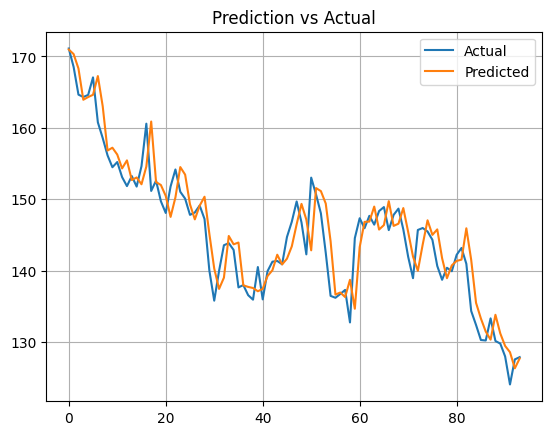

In [11]:
symbol = 'AAPL'
df = fetch_data(symbol, '2020-01-01', '2023-01-01')
train, val, test, scaler = split_scale(df)
seq_length = 20
train_ds = StockDataset(torch.FloatTensor(train), seq_length)
val_ds = StockDataset(torch.FloatTensor(val), seq_length)
test_ds = StockDataset(torch.FloatTensor(test), seq_length)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)
model = LSTMModel().to(device)
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=150)
evaluate(model, test_loader, scaler)

# Export to ONNX


In [13]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 15.5 MB/s eta 0:00:00


In [14]:
def export_onnx(model, seq_length=20, path="model.onnx"):
    model.eval()
    dummy_input = torch.randn(1, seq_length, 6).to(device)
    torch.onnx.export(
        model,
        dummy_input,
        path,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
        opset_version=11
    )
    print(f"Model exported to ONNX format at {path}")
export_onnx(model)

/tmp/ipykernel_6721/1908253904.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0403 04:46:09.012000 6721 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `LSTMModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LSTMModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:67: adapter_lookup: Assertion `false`

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 2 of general pattern rewrite rules.
Model exported to ONNX format at model.onnx


# Loss Visualization

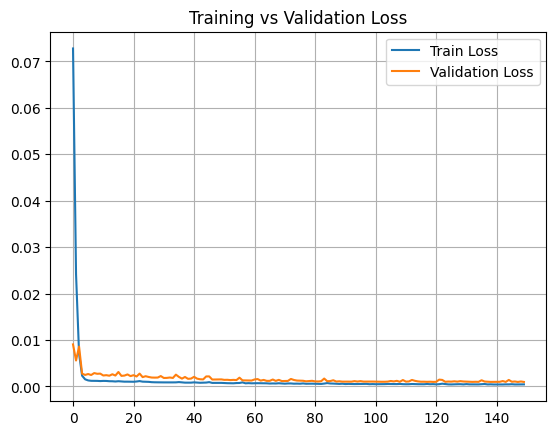

In [15]:
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.grid(True)
plt.title("Training vs Validation Loss")
plt.show()